In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

def exp(x,A, tau):
    return A*np.exp(x/tau)


def lin1(x,a,b):
    return x*a+b

def lin2(x, x0,a, b):
    return (x-x0)*a+b


def sort_pd(pdarray: pd.core.frame.DataFrame, col_nam: str):
    arg_sort = np.argsort(pdarray[col_nam].values)
    columns = pdarray.columns
    pdarray_val = pdarray.values[arg_sort][::-1]
    return pd.DataFrame(data = pdarray_val, columns = columns)

C:\Users\erick\AppData\Local\Temp\ipykernel_27888\4210438127.py:8: RuntimeWarning: invalid value encountered in sqrt
  print('m = ' + str(par1[0]) + ' +- ' + str(np.sqrt(cov1)[0,0]) + '\n'+
C:\Users\erick\AppData\Local\Temp\ipykernel_27888\4210438127.py:9: RuntimeWarning: invalid value encountered in sqrt
  'b = ' + str(par1[1]) + ' +- ' + str(np.sqrt(cov1)[1,1]))


m = 227.4153846154444 +- 5.064980949032322
b = -318.9046153853328 +- 70.90973358133361
r2 = 0.9887197947811207

x0 = 27.22637695714535 +- 6721167.802940853
m = 4636.912161349944 +- 80.20820907296826
b = 16008.195464958862 +- 31165464725.540684
r2 = 0.9974028932908777

In the second period (> 2013-01-01), the number of orders per month is 20.4 larger than the first period (< 2013-01-01)



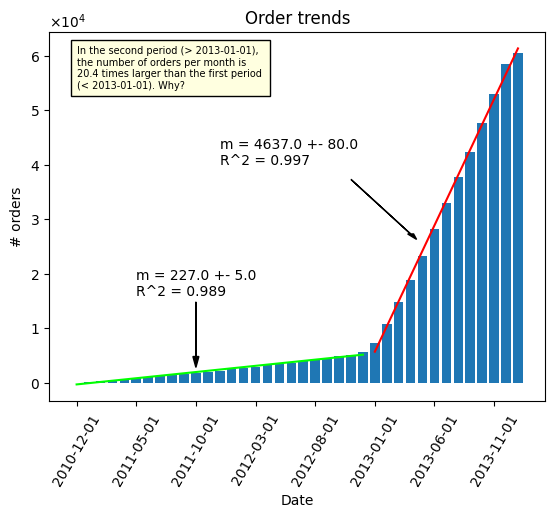

In [241]:
cat_sales = pd.read_csv('dat_order_trends.csv', delimiter=';', header=0)

array_aux = np.array([i for i in range(0,len(cat_sales['Date']))])

par1, cov1 = curve_fit(lin1, array_aux[:25], cat_sales['Orders'][:25], p0 = [200, 10])
y_mod1 = lin1(array_aux, *par1)
r2_1 = r2_score(cat_sales['Orders'][:25], y_mod1[:25])
print('m = ' + str(par1[0]) + ' +- ' + str(np.sqrt(cov1)[0,0]) + '\n'+
      'b = ' + str(par1[1]) + ' +- ' + str(np.sqrt(cov1)[1,1]))
print('r2 = ' + str(r2_1) + '\n')


par2, cov2 = curve_fit(lin2, array_aux[25:], cat_sales['Orders'][25:], p0 = [25, 4000, 10000])
y_mod2 = lin2(array_aux, *par2)
r2_2 = r2_score(cat_sales['Orders'][25:], y_mod2[25:])
print('x0 = '+ str(par2[0]) + ' +- ' + str(np.sqrt(cov2)[0,0]) + '\n' +
      'm = ' + str(par2[1]) + ' +- ' + str(np.sqrt(cov2)[1,1]) + '\n' +
      'b = ' + str(par2[2]) + ' +- ' + str(np.sqrt(cov2)[2,2]))
print('r2 = ' + str(r2_2) + '\n')



print('In the second period (> 2013-01-01), the number of orders per month is ' +
       str(round(par2[1]/par1[0],1)) + ' larger than the first period (< 2013-01-01)\n')


plt.bar(array_aux, cat_sales['Orders'])
plt.plot(array_aux[:25], y_mod1[:25], color = [0,1,0])
plt.plot(array_aux[25:], y_mod2[25:], color = [1,0,0])
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0),useMathText = True)
plt.xticks(ticks = np.array(range(0,40,5)), 
           labels = cat_sales['Date'].values[np.array(range(0,40,5))],
           rotation = 60)

plt.xlabel('Date')
plt.ylabel('# orders')
plt.arrow(10, cat_sales['Orders'][10]+13000, 0, -10000,head_width=0.5,
    head_length=2000,
    fc='black',
    ec='black')
plt.text(5, 16000, f'm = {np.round(par1[0], 0)} +- {np.round(np.sqrt(cov1[0,0]), 0)} \nR^2 = {np.round(r2_1,3)}')

plt.arrow(23, cat_sales['Orders'][25]+30000, 5, -10000,head_width=0.5,
    head_length=1000,
    fc='black',
    ec='black')
plt.text(12, 40000, f'm = {np.round(par2[1], 0)} +- {np.round(np.sqrt(cov2[1,1]), 0)} \nR^2 = {np.round(r2_2,3)}')
plt.text(0,54000,'In the second period (> 2013-01-01), \nthe number of orders per month is \n20.4 times larger than the first period \n(< 2013-01-01). Why?', 
        size = 7,
        bbox=dict(facecolor='lightyellow', edgecolor='black' ))
plt.title('Order trends')
plt.show()




Text(0.5, 0, 'Category')

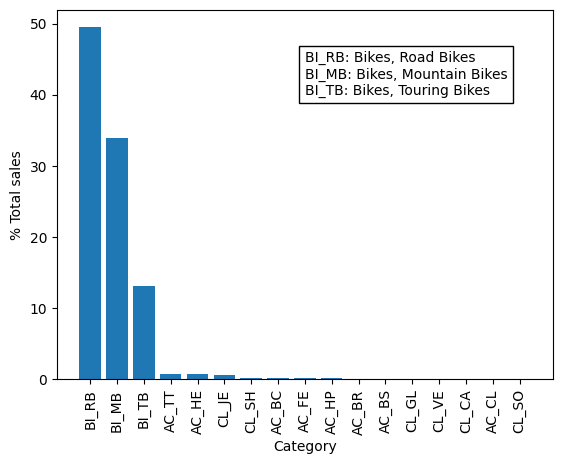

In [244]:
dcs = pd.read_csv('dat_category_sales.csv', delimiter=';', header=0)
dcs = sort_pd(dcs, 'Ptg_sls')
array_aux2 = np.array(range(0,len(dcs)))
# {dcs['Category'][0]}, {dcs['Subcateogry'][0]}
plt.bar(array_aux2, dcs['Ptg_sls'])
plt.text(8,40, f"{dcs['ID_CAT'][0]}: {dcs['Category'][0]}, {dcs['Subcategory'][0]}\n"+
        f"{dcs['ID_CAT'][1]}: {dcs['Category'][1]}, {dcs['Subcategory'][1]}\n"+
        f"{dcs['ID_CAT'][2]}: {dcs['Category'][2]}, {dcs['Subcategory'][2]}" , 
        size = 10,
        bbox=dict(facecolor='white', edgecolor='black' ))
plt.xticks(ticks = array_aux2, 
           labels = dcs['ID_CAT'],
           rotation = 90)
plt.ylabel('% Total sales')
plt.xlabel('Category')

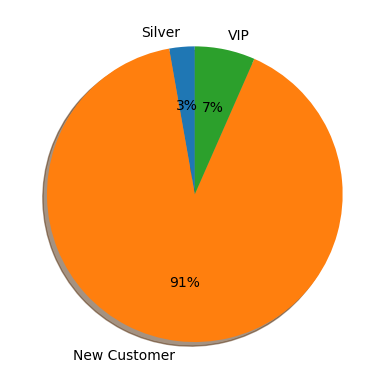

In [233]:
cst_sts = pd.read_csv('dat_cst_status.csv', delimiter=';', header=None)
cst_sts.loc[1,0] = 'New Customer'

plt.pie(cst_sts[1], labels=cst_sts[0],startangle=90,shadow=True,
    autopct='%1.0f%%')
plt.show()